# 301 — scRNA-seq SCT Gaussian Full Analysis

**Companion to:** `300_scrna_sct_gaussian_k_sweep.ipynb`  
**Mirrors:** `101_pdx2_nb_full_analysis.ipynb` adapted for a **Gaussian decoder** on SCT Pearson residuals.

**Input:**
- K-sweep runs at `outputs/{SAMPLE}_sct_gaussian_k_sweep/runs/k{K}_seed{SEED}/`
- Processed H5AD at `data/{SAMPLE}_sct_pearson_residuals_hvg.h5ad`
- Config from `configs/sct_gaussian_k_sweep.yaml`

**Artifacts in each run dir (Gaussian decoder):**
- `training_log.csv` — epoch-level losses  
- `weights/cell_weights.csv` — cell_id, split, w_0..w_{K-1}  
- `archetypes/archetype_means.csv` — archetype × gene (real-valued Pearson residual means)  
- `archetypes/archetype_vars.csv` — archetype × gene (per-gene σ²)  
- `archetypes/archetype_logvars.csv` — log variance  
- `archetypes/pure_archetype_means.csv` — pure archetype means  
- `metrics/val_diagnostics.csv` — cell_id, nll, squared_error, mean_abs_standardized_residual  
- `metrics/test_diagnostics.csv` — same columns  
- `metrics/val_metrics.json` — per-gene MSE, nll_mean, nll_std

**Figures produced:**
1. Archetype mean heatmap (RdBu_r, diverging)  
2. Training convergence  
3. UMAP by dominant archetype + effective K  
4. Mean composition by split  
5. Weight pairwise relationships  
6. Effective K distribution  
7. Top genes per archetype (signed horizontal bars)  
8. Weight distributions by split (violin)  
9. Per-cell Gaussian reconstruction diagnostics  
10. Per-gene learned variance summary  
11. Bootstrap stability  
12. External signature matching (H5Seurat)


In [1]:
from pathlib import Path
import sys


def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root')


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

print('Repo root:', REPO_ROOT)


Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv


## Step 1 — Config + Paths

Reads `configs/sct_gaussian_k_sweep.yaml` for `sample:` and sets all derived paths.

**User controls** — edit `SELECT_K`, `SELECT_SEED`, and the H5Seurat path below.

In [3]:
import json
import re
import warnings
import subprocess

import h5py
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy import sparse
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 140,
    'savefig.dpi': 220,
    'savefig.bbox': 'tight',
})

# --------------------------------------------------------------------------
# User Controls
# --------------------------------------------------------------------------
SELECT_K = 6             # change to desired K
SELECT_SEED = 'best'     # 'best' or integer seed
FORCE_RECOMPUTE_UMAP = False
TOP_GENES_PER_ARCH = 12
MAX_CELLS_FOR_PLOTTING = 100_000
MAX_SIGNATURES_HEATMAP = 24

# --------------------------------------------------------------------------
# Config
# --------------------------------------------------------------------------
CONFIG_PATH = REPO_ROOT / 'configs' / 'sct_gaussian_k_sweep.yaml'
assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'

with CONFIG_PATH.open('r', encoding='utf-8') as _f:
    _cfg = yaml.safe_load(_f)

SAMPLE = str(_cfg['sample'])   # 'PDX_02' or 'BCK_44'

# --------------------------------------------------------------------------
# Derived paths
# --------------------------------------------------------------------------
SWEEP_RUNS_DIR = REPO_ROOT / 'outputs' / f'{SAMPLE}_sct_gaussian_k_sweep' / 'runs'
H5AD_PATH      = REPO_ROOT / 'data' / f'{SAMPLE}_sct_pearson_residuals_hvg.h5ad'
OUT_DIR        = REPO_ROOT / f'reports/{SAMPLE}_gaussian_k{SELECT_K}'
FIG_DIR        = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Signature file (skip gracefully if not found)
H5SEURAT_SIGNATURE_PATH = (
    Path('/Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Output')
    / f'{SAMPLE}.RNA.SCT_UCell_tumor.h5seurat'
)
SIGNATURE_REGEX = r'(_UCell$)|(^sig_)'

print(f'Sample         : {SAMPLE}')
print(f'Sweep runs dir : {SWEEP_RUNS_DIR}')
print(f'H5AD path      : {H5AD_PATH}')
print(f'Signature file : {H5SEURAT_SIGNATURE_PATH}')
print(f'Report dir     : {OUT_DIR}')
print(f'SELECT_K={SELECT_K}  SELECT_SEED={SELECT_SEED}')


Sample         : PDX_02
Sweep runs dir : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDX_02_sct_gaussian_k_sweep/runs
H5AD path      : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/PDX_02_sct_pearson_residuals_hvg.h5ad
Signature file : /Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Output/PDX_02.RNA.SCT_UCell_tumor.h5seurat
Report dir     : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/reports/PDX_02_gaussian_k6
SELECT_K=6  SELECT_SEED=best


## Step 2 — Resolve Best Run

Scans `SWEEP_RUNS_DIR` for `k{K}_seed{S}` directories and picks the seed with the
lowest `val_recon` (falling back to `val_nll` or `val_loss`).

In [4]:
# Resolve selected run from sweep outputs
assert SWEEP_RUNS_DIR.exists(), f'Missing sweep run directory: {SWEEP_RUNS_DIR}'

run_rows = []
pat = re.compile(r'^k(?P<k>\d+)_seed(?P<seed>\d+)$')

for p in sorted(SWEEP_RUNS_DIR.iterdir()):
    if not p.is_dir():
        continue
    m = pat.match(p.name)
    if m is None:
        continue
    k = int(m.group('k'))
    seed = int(m.group('seed'))

    hist_path = p / 'training_log.csv'
    if not hist_path.exists():
        continue
    hist_tmp = pd.read_csv(hist_path)

    if 'val_recon' in hist_tmp.columns:
        best_val = float(hist_tmp['val_recon'].min())
        best_col = 'val_recon'
    elif 'val_nll' in hist_tmp.columns:
        best_val = float(hist_tmp['val_nll'].min())
        best_col = 'val_nll'
    else:
        best_val = float(hist_tmp['val_loss'].min())
        best_col = 'val_loss'

    run_rows.append({
        'k': k,
        'seed': seed,
        'run_dir': p,
        'best_val': best_val,
        'best_col': best_col,
        'n_epochs': len(hist_tmp),
    })

runs_df = pd.DataFrame(run_rows)
if len(runs_df) == 0:
    raise RuntimeError('No completed runs found in sweep directory.')

runs_k = runs_df[runs_df['k'] == int(SELECT_K)].copy()
if len(runs_k) == 0:
    raise RuntimeError(
        f'No runs found for K={SELECT_K}. '
        f'Available K: {sorted(runs_df.k.unique().tolist())}'
    )

if SELECT_SEED == 'best':
    pick = runs_k.sort_values('best_val', ascending=True).iloc[0]
else:
    seed_int = int(SELECT_SEED)
    sub = runs_k[runs_k['seed'] == seed_int]
    if len(sub) == 0:
        raise RuntimeError(f'No run found for K={SELECT_K}, seed={seed_int}')
    pick = sub.iloc[0]

RUN_DIR  = Path(pick['run_dir'])
SEED     = int(pick['seed'])
BEST_COL = str(pick['best_col'])

print('Selected run:', RUN_DIR)
print(f'K={SELECT_K}, seed={SEED}, best {BEST_COL}={pick.best_val:.6f}')
print('\nAll runs for selected K:')
display(runs_k.sort_values('best_val').reset_index(drop=True))


Selected run: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/PDX_02_sct_gaussian_k_sweep/runs/k6_seed42
K=6, seed=42, best val_recon=229.900253

All runs for selected K:


,k,seed,run_dir,best_val,best_col,n_epochs
0,6,42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,229.900253,val_recon,500


## Step 3 — Load Artifacts

Loads the H5AD, archetype means/vars, cell weights, and training history.

In [5]:
# Load H5AD
assert H5AD_PATH.exists(), f'Missing H5AD: {H5AD_PATH}'
adata = sc.read_h5ad(H5AD_PATH)
print(f'h5ad loaded: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

# Archetype artifact paths
means_path    = RUN_DIR / 'archetypes' / 'archetype_means.csv'
vars_path     = RUN_DIR / 'archetypes' / 'archetype_vars.csv'
logvars_path  = RUN_DIR / 'archetypes' / 'archetype_logvars.csv'
hist_path     = RUN_DIR / 'training_log.csv'
weights_path  = RUN_DIR / 'weights' / 'cell_weights.csv'

for _p in [means_path, hist_path, weights_path]:
    if not _p.exists():
        raise FileNotFoundError(f'Missing expected artifact: {_p}')

means_df   = pd.read_csv(means_path, index_col=0)      # archetype × gene
hist       = pd.read_csv(hist_path)
weights_all = pd.read_csv(weights_path)

if vars_path.exists():
    vars_df = pd.read_csv(vars_path, index_col=0)
else:
    vars_df = None
    print('archetype_vars.csv not found — Fig 10 will be skipped.')

K      = means_df.shape[0]
W_COLS = [c for c in weights_all.columns if c.startswith('w_')]
assert len(W_COLS) == K, f'Expected {K} weight columns, found {len(W_COLS)}'

COMP_NAMES = [f'A{i}' for i in range(K)]
means_df.index = COMP_NAMES
if vars_df is not None:
    vars_df.index = COMP_NAMES

palette = sns.color_palette('tab10', K)

print(f'Archetypes  : {COMP_NAMES}')
print(f'Training epochs: {len(hist)}')
print(f'Best {BEST_COL}: {hist[BEST_COL].min():.6f}')
print(f'Weights rows: {len(weights_all)}')
print(f'Training cols: {list(hist.columns)}')


h5ad loaded: 5,774 cells x 100 genes
Archetypes  : ['A0', 'A1', 'A2', 'A3', 'A4', 'A5']
Training epochs: 500
Best val_recon: 229.900253
Weights rows: 5774
Training cols: ['epoch', 'train_loss', 'train_recon', 'train_nll', 'train_entropy', 'train_diversity', 'train_var_reg', 'val_loss', 'val_recon', 'val_nll', 'val_entropy', 'val_diversity', 'val_var_reg']


In [6]:
# Align weights to adata and compute derived fields
if 'cell_id' in adata.obs.columns:
    adata.obs['cell_id'] = adata.obs['cell_id'].astype(str)
else:
    adata.obs['cell_id'] = adata.obs_names.astype(str)

w = weights_all.copy()
w['cell_id'] = w['cell_id'].astype(str)

obs_df = adata.obs[['cell_id']].copy()
obs_df = obs_df.reset_index().rename(columns={'index': 'obs_name'})
merged = obs_df.merge(w, on='cell_id', how='inner')

if len(merged) == 0:
    raise RuntimeError('No aligned cells between H5AD and weight table.')

W_mat = merged[W_COLS].to_numpy(dtype=float)
merged['dominant']      = np.argmax(W_mat, axis=1)
merged['dominant_name'] = merged['dominant'].map({i: f'A{i}' for i in range(K)})
merged['entropy']       = -(np.clip(W_mat, 1e-12, 1.0) * np.log(np.clip(W_mat, 1e-12, 1.0))).sum(axis=1)
merged['effective_k']   = np.exp(merged['entropy'])

adata_sub = adata[merged['obs_name'].values].copy()

# Determine which columns exist in weights (split may or may not be present)
_extra = [c for c in ['split'] if c in merged.columns]
for col in [*_extra, 'dominant', 'dominant_name', 'entropy', 'effective_k', *W_COLS]:
    adata_sub.obs[col] = merged[col].values

# If no split column present, assign all cells to 'all'
if 'split' not in adata_sub.obs.columns:
    adata_sub.obs['split'] = 'all'

print(f'Aligned cells: {adata_sub.n_obs:,} / {adata.n_obs:,}')
print('Split counts:')
print(adata_sub.obs['split'].value_counts())


Aligned cells: 5,774 / 5,774
Split counts:
split
train    4041
test      867
val       866
Name: count, dtype: int64


## Step 4 — UMAP

Computes PCA directly on the SCT Pearson residuals (already standardized — no log1p needed),
then runs neighbors + UMAP.

In [7]:
# UMAP on Pearson residuals (already standardized; no log1p)
if FORCE_RECOMPUTE_UMAP or ('X_umap' not in adata_sub.obsm):
    adata_vis = adata_sub.copy()

    # Ensure dense float32 for PCA
    if sparse.issparse(adata_vis.X):
        X_pr = np.asarray(adata_vis.X.todense(), dtype=np.float32)
    else:
        X_pr = np.asarray(adata_vis.X, dtype=np.float32)

    # Clip extreme values for numerical stability (Pearson residuals can have outliers)
    X_pr = np.clip(X_pr, -10.0, 10.0)
    adata_vis.X = X_pr

    sc.pp.pca(adata_vis, n_comps=min(50, adata_vis.n_vars - 1))
    sc.pp.neighbors(adata_vis, n_neighbors=15, n_pcs=min(30, adata_vis.obsm['X_pca'].shape[1]))
    sc.tl.umap(adata_vis, random_state=42)

    adata_sub.obsm['X_umap'] = adata_vis.obsm['X_umap'].copy()
    print('UMAP computed.')
else:
    print('UMAP already present — skipping recompute.')

print('UMAP ready:', 'X_umap' in adata_sub.obsm)


UMAP computed.
UMAP ready: True


## Figure 1 — Archetype Mean Heatmap

Shows the top `TOP_GENES_PER_ARCH` genes per archetype by |mean| Pearson residual.
Uses a **diverging RdBu_r** colormap because means can be negative.

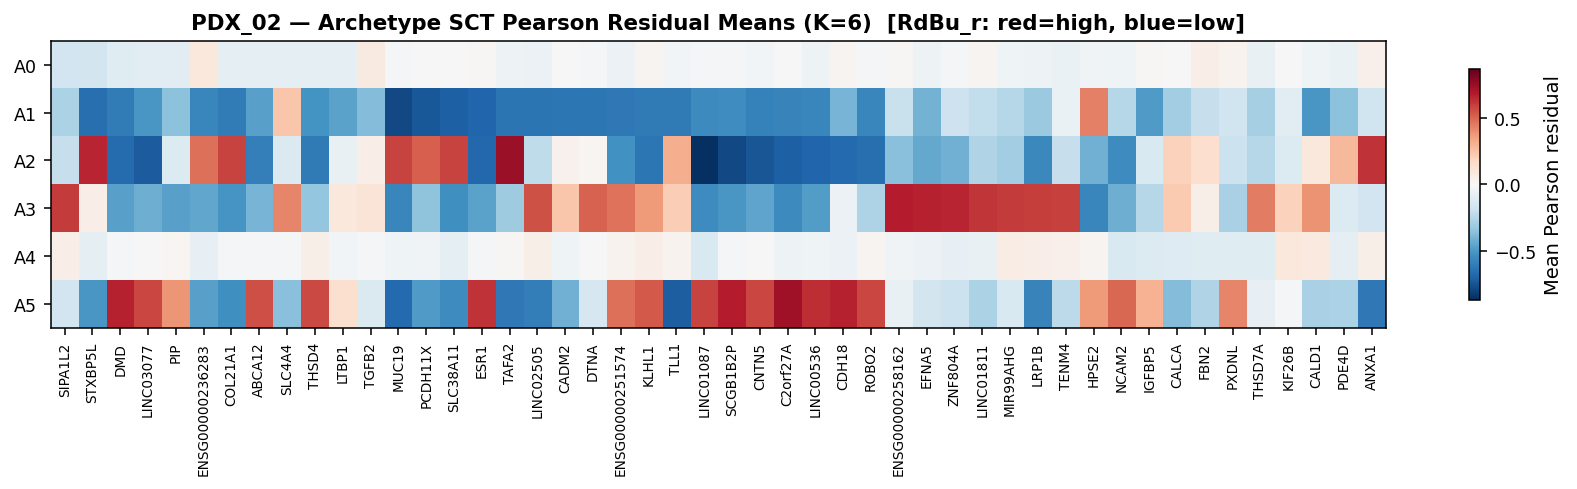

Saved fig1


In [8]:
# Figure 1: Archetype mean heatmap (RdBu_r diverging)
selected_genes = []
for arch in COMP_NAMES:
    top = means_df.loc[arch].abs().sort_values(ascending=False).head(TOP_GENES_PER_ARCH).index.tolist()
    selected_genes.extend(top)

# Unique, order-preserving
seen = set()
gene_panel = []
for g in selected_genes:
    if g not in seen:
        seen.add(g)
        gene_panel.append(g)

mat = means_df[gene_panel].values  # K x n_genes_panel
vabs = np.nanmax(np.abs(mat))
vabs = max(vabs, 0.5)  # ensure non-zero range

fig, ax = plt.subplots(figsize=(max(10, len(gene_panel) * 0.26), max(3.5, K * 0.6)))
im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
ax.set_xticks(range(len(gene_panel)))
ax.set_xticklabels(gene_panel, rotation=90, fontsize=7)
ax.set_yticks(range(K))
ax.set_yticklabels(COMP_NAMES)
ax.set_title(
    f'{SAMPLE} — Archetype SCT Pearson Residual Means (K={K})  [RdBu_r: red=high, blue=low]',
    fontweight='bold'
)
plt.colorbar(im, ax=ax, label='Mean Pearson residual', shrink=0.8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_archetype_means_heatmap.png')
fig.savefig(FIG_DIR / 'fig1_archetype_means_heatmap.pdf')
plt.show()
print('Saved fig1')


In [13]:
adata_sub.obs

,cell_id,split,dominant,dominant_name,entropy,effective_k,w_0,w_1,w_2,w_3,w_4,w_5
AAACAGCCACAGGAAT-1,AAACAGCCACAGGAAT-1,train,2,A2,2.119361e-03,1.002122,5.282862e-10,1.629884e-04,9.997888e-01,4.658739e-05,9.935263e-10,1.646290e-06
AAACAGCCAGGCGAGT-1,AAACAGCCAGGCGAGT-1,train,2,A2,3.768784e-02,1.038407,8.702291e-10,2.845642e-06,9.938146e-01,6.177592e-03,1.236515e-09,4.986979e-06
AAACATGCAATGCCCG-1,AAACATGCAATGCCCG-1,train,2,A2,1.227398e-03,1.001228,5.326264e-20,1.877054e-14,9.998773e-01,1.226659e-04,5.695923e-20,9.941321e-13
AAACATGCAGGAACTG-1,AAACATGCAGGAACTG-1,train,2,A2,6.539537e-01,1.923129,1.134094e-08,2.309772e-06,6.393907e-01,3.605930e-01,8.778158e-09,1.392683e-05
AAACCAACAAATACCT-1,AAACCAACAAATACCT-1,train,2,A2,6.309142e-06,1.000006,2.233008e-20,4.980107e-11,9.999996e-01,5.166244e-13,1.431109e-18,4.040182e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCCCTGACT-1,TTTGTGTTCCCTGACT-1,train,3,A3,6.005458e-02,1.061895,1.306595e-09,1.457790e-07,1.075449e-02,9.891886e-01,1.491578e-09,5.681699e-05
TTTGTGTTCCGTGACA-1,TTTGTGTTCCGTGACA-1,train,1,A1,1.674519e-01,1.182288,1.110160e-06,9.618168e-01,1.066037e-03,3.705674e-02,8.263409e-07,5.863207e-05
TTTGTGTTCTCCTCTT-1,TTTGTGTTCTCCTCTT-1,train,2,A2,1.263620e-05,1.000013,6.276483e-16,8.379531e-07,9.999992e-01,2.258006e-09,2.497966e-15,1.802582e-09
TTTGTTGGTACAATGT-1,TTTGTTGGTACAATGT-1,test,2,A2,3.930012e-02,1.040083,1.199032e-08,1.502303e-04,9.943054e-01,1.801518e-03,5.264155e-08,3.742728e-03


## Figure 2 — Training Convergence

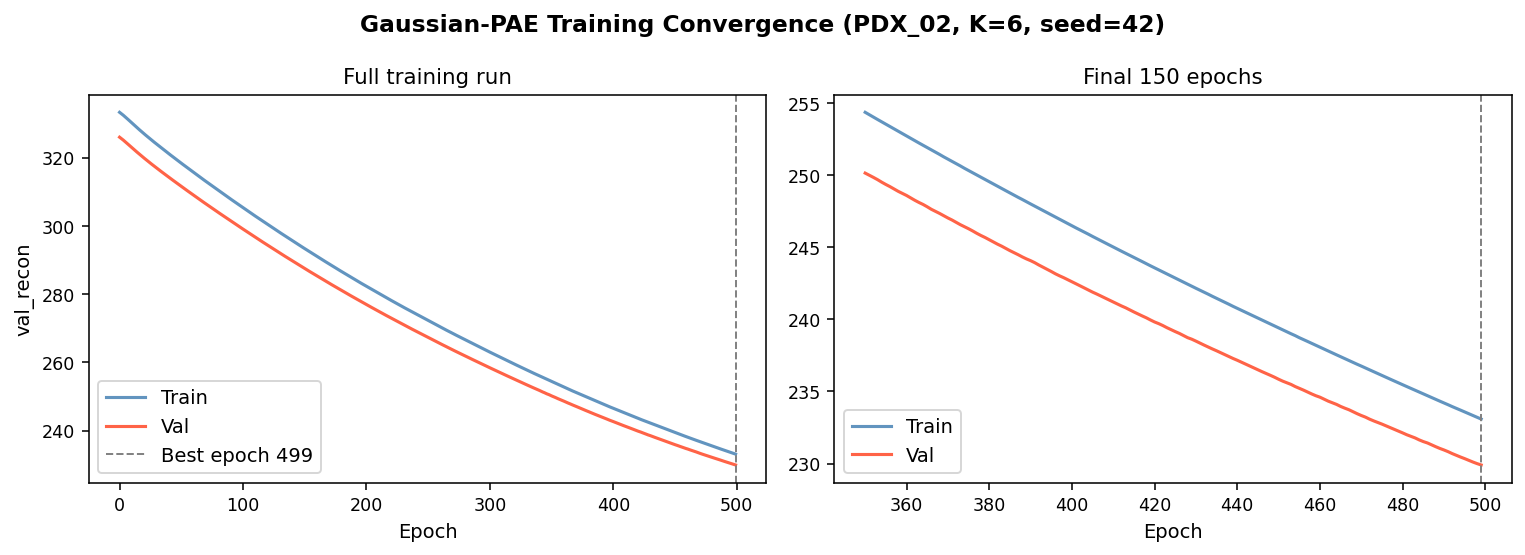

Saved fig2


In [9]:
# Figure 2: Training convergence — full run + zoomed last 150 epochs
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
best_epoch = int(hist[BEST_COL].idxmin())

train_col = 'train_recon' if 'train_recon' in hist.columns else 'train_loss'

axes[0].plot(hist.index, hist[train_col],
             label='Train', color='steelblue', lw=1.6, alpha=0.85)
axes[0].plot(hist.index, hist[BEST_COL],
             label='Val', color='tomato', lw=1.6)
axes[0].axvline(best_epoch, color='gray', ls='--', lw=1,
                label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel(BEST_COL)
axes[0].set_title('Full training run')
axes[0].legend()

n_tail = min(150, len(hist))
tail = hist.tail(n_tail)
axes[1].plot(tail.index, tail[train_col],
             color='steelblue', lw=1.6, alpha=0.85, label='Train')
axes[1].plot(tail.index, tail[BEST_COL],
             color='tomato', lw=1.6, label='Val')
if best_epoch >= (len(hist) - n_tail):
    axes[1].axvline(best_epoch, color='gray', ls='--', lw=1)
axes[1].set_title(f'Final {n_tail} epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.suptitle(
    f'Gaussian-PAE Training Convergence ({SAMPLE}, K={K}, seed={SEED})',
    fontweight='bold'
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_training_convergence.png')
fig.savefig(FIG_DIR / 'fig2_training_convergence.pdf')
plt.show()
print('Saved fig2')


## Figure 3 — UMAP by Dominant Archetype + Effective K

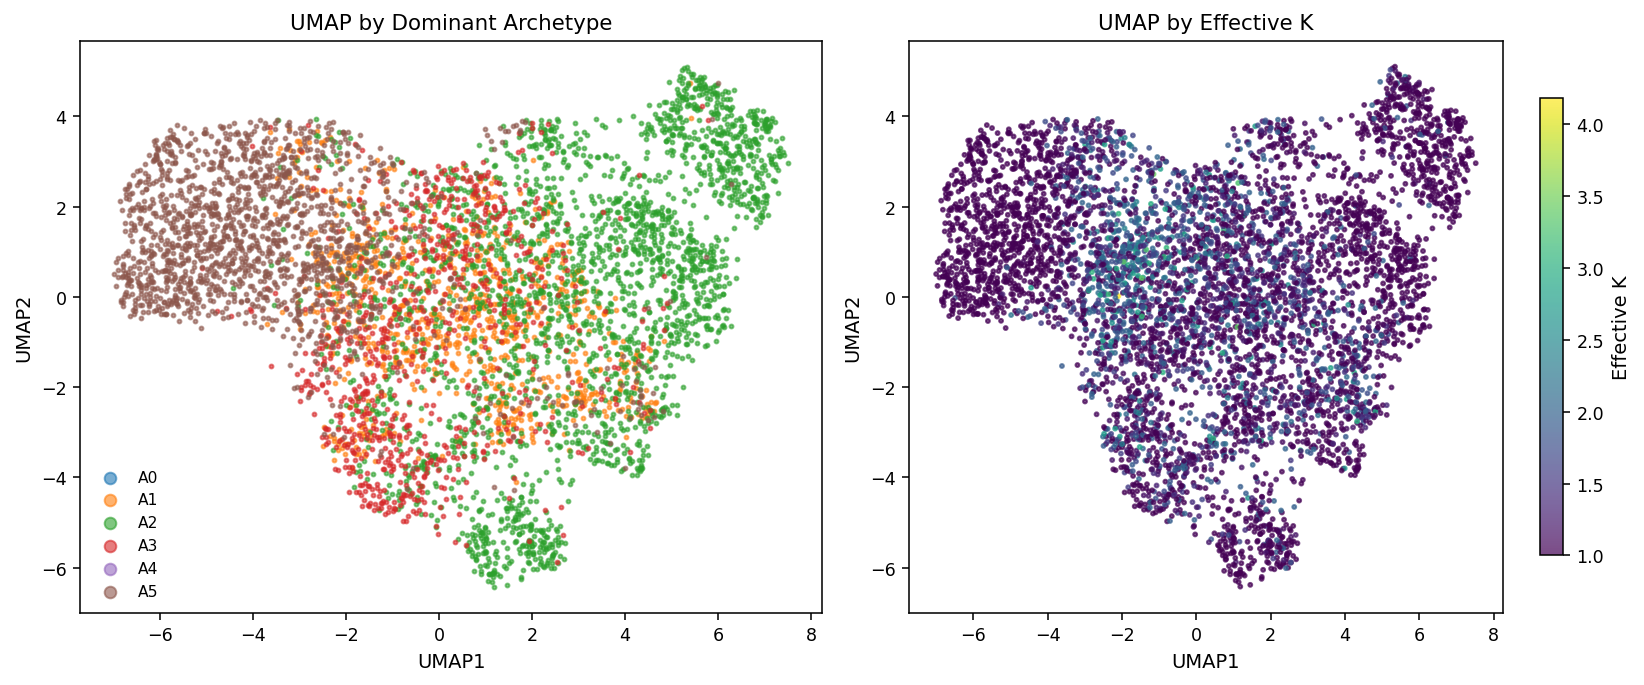

Saved fig3


In [10]:
# Figure 3: UMAP colored by dominant archetype and effective K
coords = adata_sub.obsm['X_umap']

if adata_sub.n_obs > MAX_CELLS_FOR_PLOTTING:
    rng = np.random.default_rng(42)
    idx = rng.choice(adata_sub.n_obs, size=MAX_CELLS_FOR_PLOTTING, replace=False)
else:
    idx = np.arange(adata_sub.n_obs)

coords_s = coords[idx]
dom_s    = adata_sub.obs['dominant'].to_numpy()[idx]
eff_s    = adata_sub.obs['effective_k'].to_numpy()[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for k_i in range(K):
    m = dom_s == k_i
    axes[0].scatter(coords_s[m, 0], coords_s[m, 1],
                    s=4, alpha=0.6, color=palette[k_i], label=f'A{k_i}')
axes[0].set_title('UMAP by Dominant Archetype')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].legend(markerscale=3, fontsize=8, frameon=False)

scm = axes[1].scatter(coords_s[:, 0], coords_s[:, 1],
                      c=eff_s, s=4, alpha=0.7, cmap='viridis')
axes[1].set_title('UMAP by Effective K')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
plt.colorbar(scm, ax=axes[1], label='Effective K', shrink=0.8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_umap_composition.png')
fig.savefig(FIG_DIR / 'fig3_umap_composition.pdf')
plt.show()
print('Saved fig3')


## Figure 4 — Mean Composition by Split

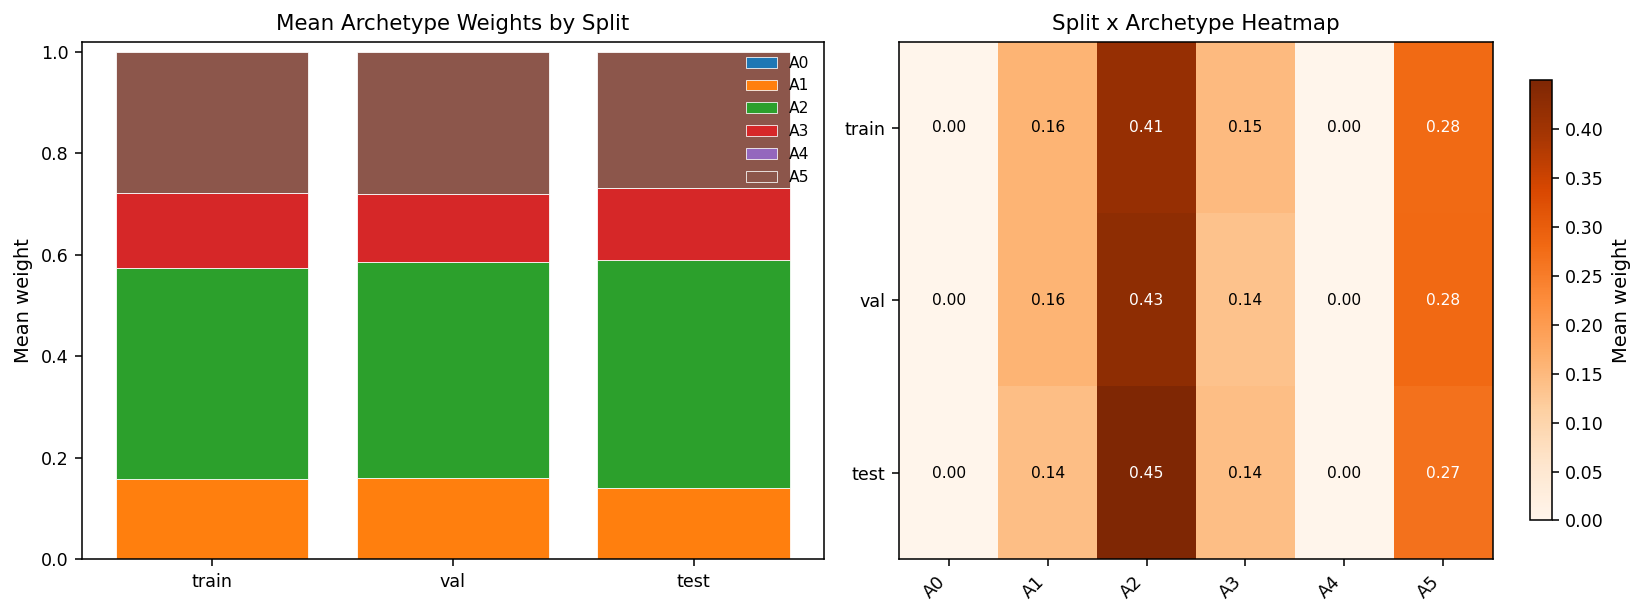

Saved fig4


In [11]:
# Figure 4: Composition by split
splits_present = [s for s in ['train', 'val', 'test', 'all']
                  if s in adata_sub.obs['split'].unique()]
split_mean = (
    adata_sub.obs.groupby('split')[W_COLS]
    .mean()
    .reindex(splits_present)
    .fillna(0)
)
split_mean.columns = COMP_NAMES

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

x      = np.arange(len(split_mean.index))
bottom = np.zeros(len(x))
for i, comp in enumerate(COMP_NAMES):
    vals = split_mean[comp].values
    axes[0].bar(x, vals, bottom=bottom, color=palette[i], label=comp,
                edgecolor='white', linewidth=0.4)
    bottom += vals
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_mean.index)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel('Mean weight')
axes[0].set_title('Mean Archetype Weights by Split')
axes[0].legend(fontsize=8, frameon=False, loc='upper right')

vmax_heat = max(0.35, float(split_mean.values.max()))
im = axes[1].imshow(split_mean.values, aspect='auto', cmap='Oranges',
                    vmin=0, vmax=vmax_heat)
axes[1].set_xticks(range(K))
axes[1].set_xticklabels(COMP_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(len(split_mean.index)))
axes[1].set_yticklabels(split_mean.index)
axes[1].set_title('Split x Archetype Heatmap')
for i in range(split_mean.shape[0]):
    for j in range(split_mean.shape[1]):
        v = split_mean.iloc[i, j]
        axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if v > 0.22 else 'black')
plt.colorbar(im, ax=axes[1], label='Mean weight', shrink=0.85)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_split_composition.png')
fig.savefig(FIG_DIR / 'fig4_split_composition.pdf')
plt.show()
print('Saved fig4')


## Figure 5 — Weight Pairwise Relationships

In [ ]:
# Figure 5: Archetype weight pairwise relationships
W_plot = adata_sub.obs[W_COLS].to_numpy(dtype=float)
corr   = np.corrcoef(W_plot.T)

fig, axes = plt.subplots(K, K, figsize=(2.1 * K + 2, 2.1 * K + 2))
if K == 1:
    axes = np.array([[axes]])

for i in range(K):
    for j in range(K):
        ax = axes[i, j]
        if i == j:
            ax.hist(W_plot[:, i], bins=50, color=palette[i], alpha=0.85, density=True)
            ax.set_xlim(0, 1)
        else:
            ax.hexbin(W_plot[:, j], W_plot[:, i], gridsize=35, cmap='Blues', mincnt=1)
            ax.text(0.05, 0.90, f'r={corr[i, j]:.2f}',
                    transform=ax.transAxes, fontsize=7, color='darkred')
        if i == K - 1:
            ax.set_xlabel(f'A{j}', fontsize=8)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(f'A{i}', fontsize=8)
        else:
            ax.set_yticklabels([])

fig.suptitle('Archetype Weight Pairwise Relationships', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig5_weight_correlations.png')
fig.savefig(FIG_DIR / 'fig5_weight_correlations.pdf')
plt.show()

print(pd.DataFrame(corr, index=COMP_NAMES, columns=COMP_NAMES).round(3).to_string())
print('Saved fig5')


## Figure 6 — Effective K Distribution

In [ ]:
# Figure 6: Effective K — histogram + by-split bar chart
eff = adata_sub.obs['effective_k'].to_numpy(dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(eff, bins=80, color='steelblue', alpha=0.85, density=True)
axes[0].axvline(eff.mean(), color='red', ls='--', lw=1.2, label=f'Mean={eff.mean():.2f}')
axes[0].set_xlabel('Effective K')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Effective K distribution (n={len(eff):,})')
axes[0].legend()

splits_bar = [s for s in ['train', 'val', 'test', 'all']
              if s in adata_sub.obs['split'].unique()]
by_split = (
    adata_sub.obs.groupby('split')['effective_k']
    .agg(['mean', 'std'])
    .reindex(splits_bar)
)
bar_colors = ['#4c78a8', '#f58518', '#54a24b', '#9ecae1']
axes[1].bar(
    range(len(by_split)),
    by_split['mean'].values,
    yerr=by_split['std'].fillna(0).values,
    capsize=4,
    color=bar_colors[:len(by_split)],
    alpha=0.8
)
axes[1].set_xticks(range(len(by_split)))
axes[1].set_xticklabels(by_split.index)
axes[1].set_ylabel('Mean effective K')
axes[1].set_ylim(0, max(1.05 * by_split['mean'].max(), float(K)))
axes[1].set_title('Effective K by split')

fig.suptitle('Polyphenic Mixing via Effective K', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_effective_k.png')
fig.savefig(FIG_DIR / 'fig6_effective_k.pdf')
plt.show()
print(f'Mean effective K: {eff.mean():.3f}')
print('Saved fig6')


## Figure 7 — Top Genes per Archetype (Signed Horizontal Bars)

Genes are ranked by |mean|; bar lengths use the **signed** mean so up-regulated
genes (positive residual) show red bars and down-regulated genes show blue bars,
matching the RdBu_r convention.

In [ ]:
# Figure 7: Top genes per archetype (signed horizontal bars, RdBu colormap)
import matplotlib.cm as _cm
import matplotlib.colors as _colors

_rdbu = _cm.get_cmap('RdBu_r')
_norm = _colors.TwoSlopeNorm(vmin=-3.0, vcenter=0.0, vmax=3.0)

n_top_bar = min(TOP_GENES_PER_ARCH, 15)
fig, axes = plt.subplots(K, 1, figsize=(10, max(2.6 * K, 6)), sharex=False)
if K == 1:
    axes = [axes]

for i, arch in enumerate(COMP_NAMES):
    row = means_df.loc[arch]
    top = row.abs().sort_values(ascending=False).head(n_top_bar)
    top_vals = row[top.index].values
    top_genes = top.index.tolist()

    bar_colors_i = [_rdbu(_norm(v)) for v in top_vals]
    y_pos = np.arange(len(top_vals))[::-1]

    bars = axes[i].barh(y_pos, top_vals, color=bar_colors_i, alpha=0.88)
    axes[i].axvline(0, color='black', lw=0.8, alpha=0.6)
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(top_genes, fontsize=8)
    axes[i].set_xlabel('Mean Pearson residual')
    axes[i].set_title(f'{arch} — top genes by |mean|')

fig.suptitle(
    f'{SAMPLE} — Archetype Gene Loadings (K={K})  [red=up, blue=down]',
    fontweight='bold'
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig7_top_genes.png')
fig.savefig(FIG_DIR / 'fig7_top_genes.pdf')
plt.show()
print('Saved fig7')


## Figure 8 — Weight Distributions by Split (Violin)

In [ ]:
# Figure 8: Per-archetype weight distributions by split
splits_viol = [s for s in ['train', 'val', 'test', 'all']
               if s in adata_sub.obs['split'].unique()]

fig, axes = plt.subplots(1, K, figsize=(max(12, 2.5 * K), 4.5), sharey=True)
if K == 1:
    axes = [axes]

for i, comp_col in enumerate(W_COLS):
    ax = axes[i]
    data = [
        adata_sub.obs.loc[adata_sub.obs['split'] == s, comp_col].to_numpy(dtype=float)
        for s in splits_viol
    ]
    positions = list(range(len(splits_viol)))
    vp = ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor(palette[i])
        body.set_alpha(0.75)
    vp['cmedians'].set_color('black')
    ax.set_xticks(positions)
    ax.set_xticklabels(splits_viol, rotation=25)
    ax.set_title(f'A{i}')
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel('Weight')

fig.suptitle('Per-Archetype Weight Distributions by Split', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig8_weight_distributions.png')
fig.savefig(FIG_DIR / 'fig8_weight_distributions.pdf')
plt.show()
print('Saved fig8')


## Figure 9 — Per-Cell Gaussian Reconstruction Diagnostics

Loads `val_diagnostics.csv` and `test_diagnostics.csv` (columns: `cell_id`, `nll`,
`squared_error`, `mean_abs_standardized_residual`).  
Left panel: violin of per-cell NLL by split.  
Right panel: scatter of per-cell MSE vs per-cell NLL (correlation check).

In [ ]:
# Figure 9: Gaussian per-cell reconstruction diagnostics
_diag_frames = []
for _split in ['val', 'test']:
    _dp = RUN_DIR / 'metrics' / f'{_split}_diagnostics.csv'
    if _dp.exists():
        _df = pd.read_csv(_dp)
        _df['split'] = _split
        _diag_frames.append(_df)
    else:
        print(f'Not found (will skip): {_dp}')

if len(_diag_frames) == 0:
    print('No per-cell Gaussian diagnostics found — skipping fig9.')
else:
    _diag = pd.concat(_diag_frames, ignore_index=True)
    print(f'Diagnostics columns: {list(_diag.columns)}')

    # Determine available columns
    _nll_col = 'nll' if 'nll' in _diag.columns else None
    _mse_col = 'squared_error' if 'squared_error' in _diag.columns else None

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

    if _nll_col is not None:
        sns.violinplot(
            data=_diag, x='split', y=_nll_col,
            ax=axes[0], inner='quartile', palette='Set2', cut=0
        )
        axes[0].set_title('Per-cell Gaussian NLL by split')
        axes[0].set_ylabel('NLL per cell')
    else:
        axes[0].text(0.5, 0.5, 'nll column not found', transform=axes[0].transAxes,
                     ha='center', va='center')

    if _nll_col is not None and _mse_col is not None:
        _x = _diag[_mse_col].to_numpy(dtype=float)
        _y = _diag[_nll_col].to_numpy(dtype=float)
        _finite = np.isfinite(_x) & np.isfinite(_y)
        axes[1].scatter(_x[_finite], _y[_finite], s=5, alpha=0.25, color='tab:blue')
        if _finite.sum() > 10:
            _r, _p = spearmanr(_x[_finite], _y[_finite])
            axes[1].text(0.03, 0.94, f'Spearman r={_r:.2f}, p={_p:.2e}',
                         transform=axes[1].transAxes, fontsize=9)
        axes[1].set_xlabel('Per-cell squared error')
        axes[1].set_ylabel('Per-cell NLL')
        axes[1].set_title('MSE vs NLL per cell')
    else:
        axes[1].text(0.5, 0.5, 'Required columns not found',
                     transform=axes[1].transAxes, ha='center', va='center')

    fig.suptitle(
        f'Gaussian Reconstruction Diagnostics ({SAMPLE}, K={K})',
        fontweight='bold'
    )
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'fig9_gaussian_diagnostics.png')
    fig.savefig(FIG_DIR / 'fig9_gaussian_diagnostics.pdf')
    plt.show()
    print('Saved fig9')


## Figure 10 — Per-Gene Learned Variance

Uses `archetype_vars.csv` (archetype × gene, σ² values).  
Left: histogram of mean per-gene σ² across archetypes.  
Right: top 20 highest-variance genes, bar-colored by the archetype with peak variance.

In [ ]:
# Figure 10: Per-gene learned variance summary
if vars_df is None:
    print('archetype_vars.csv not available — skipping fig10.')
else:
    mean_var_per_gene = vars_df.mean(axis=0)  # Series: gene -> mean σ²
    peak_arch_per_gene = vars_df.idxmax(axis=0)  # Series: gene -> archetype name with highest σ²

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    axes[0].hist(mean_var_per_gene.values, bins=60, color='mediumpurple', alpha=0.85)
    axes[0].set_xlabel(r'Mean $\sigma^2$ across archetypes')
    axes[0].set_ylabel('Genes')
    axes[0].set_title(r'Distribution of per-gene learned $\sigma^2$')
    axes[0].axvline(
        float(mean_var_per_gene.median()), color='red', ls='--', lw=1,
        label=f'Median={float(mean_var_per_gene.median()):.3f}'
    )
    axes[0].legend()

    n_top_var = 20
    top_var_genes = mean_var_per_gene.sort_values(ascending=False).head(n_top_var)
    top_var_genes_rev = top_var_genes.iloc[::-1]
    top_arch = peak_arch_per_gene[top_var_genes_rev.index]

    bar_col_map = {f'A{i}': palette[i] for i in range(K)}
    bar_colors_var = [bar_col_map.get(a, 'gray') for a in top_arch.values]

    axes[1].barh(
        top_var_genes_rev.index.tolist(),
        top_var_genes_rev.values,
        color=bar_colors_var,
        alpha=0.85
    )
    axes[1].set_xlabel(r'Mean $\sigma^2$')
    axes[1].set_title(f'Top {n_top_var} highest-variance genes\n(color = archetype with peak σ²)')

    # Legend for archetype colors
    from matplotlib.patches import Patch
    legend_patches = [Patch(color=palette[i], label=f'A{i}') for i in range(K)]
    axes[1].legend(handles=legend_patches, fontsize=7, frameon=False, loc='lower right')

    fig.suptitle(
        f'{SAMPLE} — Per-Gene Learned Variance ({K} archetypes)',
        fontweight='bold'
    )
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'fig10_gene_variance.png')
    fig.savefig(FIG_DIR / 'fig10_gene_variance.pdf')
    plt.show()
    print('Saved fig10')


## Figure 11 — Bootstrap Stability

- N=150 bootstrap samples (sampling cells with replacement).  
- Per-bootstrap: mean archetype weights + mean effective K.  
- Archetype profile reproducibility: Spearman correlation of bootstrap weight-averaged
  Pearson-residual profile vs the full-data profile.

Left panel: bar chart of mean weights with 95 % CI.  
Right panel: violin of Spearman correlations per archetype.

In [ ]:
# Figure 11: Bootstrap stability diagnostics
N_BOOT           = 150
BOOT_SAMPLE_FRAC = 1.0
BOOT_RANDOM_SEED = 42

_rng_boot = np.random.default_rng(BOOT_RANDOM_SEED)

_W_boot = adata_sub.obs[W_COLS].to_numpy(dtype=np.float32)
_X_boot = adata_sub.X
_n_cells = int(adata_sub.n_obs)
_n_draw  = max(200, int(round(_n_cells * BOOT_SAMPLE_FRAC)))

if _n_cells < 500:
    print(f'Warning: only {_n_cells} aligned cells — bootstrap estimates may be noisy.')

_eps = 1e-8

# Reference profiles: weighted mean of Pearson residuals per archetype
if sparse.issparse(_X_boot):
    _ref_profiles = np.vstack([
        np.asarray(_X_boot.T.dot(_W_boot[:, k])).ravel() / (float(_W_boot[:, k].sum()) + _eps)
        for k in range(K)
    ]).astype(np.float32)
else:
    _Xd = np.asarray(_X_boot, dtype=np.float32)
    _ref_profiles = np.vstack([
        (_W_boot[:, k] @ _Xd) / (float(_W_boot[:, k].sum()) + _eps)
        for k in range(K)
    ]).astype(np.float32)

_boot_mean_w    = np.zeros((N_BOOT, K), dtype=np.float32)
_boot_effk      = np.zeros(N_BOOT, dtype=np.float32)
_boot_prof_corr = np.full((N_BOOT, K), np.nan, dtype=np.float32)

for b in range(N_BOOT):
    _bidx = _rng_boot.integers(0, _n_cells, size=_n_draw)
    _Wb   = _W_boot[_bidx, :]
    _Xb   = (
        _X_boot[_bidx, :] if sparse.issparse(_X_boot)
        else np.asarray(_X_boot[_bidx, :], dtype=np.float32)
    )

    _boot_mean_w[b, :] = _Wb.mean(axis=0)

    _ent_b = -(np.clip(_Wb, 1e-12, 1.0) * np.log(np.clip(_Wb, 1e-12, 1.0))).sum(axis=1)
    _boot_effk[b] = float(np.exp(_ent_b).mean())

    for k in range(K):
        _wk    = _Wb[:, k]
        _denom = float(_wk.sum()) + _eps
        if sparse.issparse(_Xb):
            _prof_k = np.asarray(_Xb.T.dot(_wk)).ravel() / _denom
        else:
            _prof_k = (_wk @ _Xb) / _denom
        _r, _ = spearmanr(_ref_profiles[k], _prof_k)
        if np.isfinite(_r):
            _boot_prof_corr[b, k] = float(_r)

_mean_w_orig = _W_boot.mean(axis=0)
_mean_w_lo   = np.quantile(_boot_mean_w, 0.025, axis=0)
_mean_w_hi   = np.quantile(_boot_mean_w, 0.975, axis=0)

boot_summary_df = pd.DataFrame({
    'archetype': COMP_NAMES,
    'mean_weight_orig':      _mean_w_orig,
    'mean_weight_ci_low':    _mean_w_lo,
    'mean_weight_ci_high':   _mean_w_hi,
    'mean_weight_ci_width':  _mean_w_hi - _mean_w_lo,
    'profile_spearman_median': np.nanmedian(_boot_prof_corr, axis=0),
    'profile_spearman_p05':  np.nanquantile(_boot_prof_corr, 0.05, axis=0),
    'profile_spearman_p95':  np.nanquantile(_boot_prof_corr, 0.95, axis=0),
}).sort_values('mean_weight_orig', ascending=False).reset_index(drop=True)

_eff_orig = float(np.exp(
    -(np.clip(_W_boot, 1e-12, 1.0) * np.log(np.clip(_W_boot, 1e-12, 1.0))).sum(axis=1)
).mean())

boot_global_summary_df = pd.DataFrame([{
    'n_cells_aligned':                    _n_cells,
    'n_boot':                             N_BOOT,
    'mean_effective_k_orig':              _eff_orig,
    'mean_effective_k_ci_low':            float(np.quantile(_boot_effk, 0.025)),
    'mean_effective_k_ci_high':           float(np.quantile(_boot_effk, 0.975)),
    'median_profile_spearman_across_arch': float(np.nanmedian(
        boot_summary_df['profile_spearman_median']
    )),
}])

# Plot Figure 11
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

_means  = np.array([_mean_w_orig[i] for i in range(K)])
_los    = np.array([_mean_w_lo[i]   for i in range(K)])
_his    = np.array([_mean_w_hi[i]   for i in range(K)])
_yerr   = np.vstack([_means - _los, _his - _means])

axes[0].bar(range(K), _means, color=palette, alpha=0.8)
axes[0].errorbar(range(K), _means, yerr=_yerr, fmt='none',
                 ecolor='black', elinewidth=1.0, capsize=3)
axes[0].set_xticks(range(K))
axes[0].set_xticklabels([f'A{i}' for i in range(K)])
axes[0].set_ylim(0, min(1.0, max(0.25, float(_his.max() * 1.15))))
axes[0].set_ylabel('Mean weight')
axes[0].set_title('Bootstrap 95% CI of mean archetype weights')

_corr_long = pd.DataFrame(_boot_prof_corr, columns=COMP_NAMES).melt(
    var_name='archetype', value_name='spearman'
)
sns.violinplot(
    data=_corr_long, x='archetype', y='spearman',
    ax=axes[1], inner='quartile', palette=palette, cut=0
)
axes[1].set_ylim(0, 1.01)
axes[1].set_ylabel('Spearman(ref profile, bootstrap profile)')
axes[1].set_title('Archetype profile reproducibility (Spearman vs full-data)')

fig.suptitle('Bootstrap Stability Diagnostics', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig11_bootstrap_stability.png')
fig.savefig(FIG_DIR / 'fig11_bootstrap_stability.pdf')
plt.show()

_bsum_path   = OUT_DIR / 'bootstrap_archetype_stability.csv'
_bglobal_path = OUT_DIR / 'bootstrap_global_stability.csv'
boot_summary_df.to_csv(_bsum_path, index=False)
boot_global_summary_df.to_csv(_bglobal_path, index=False)

print('Saved fig11')
print('Saved:', _bsum_path)
print('Saved:', _bglobal_path)
print('\nGlobal bootstrap summary:')
display(boot_global_summary_df.round(4))
print('\nArchetype bootstrap summary:')
display(boot_summary_df.round(4))


## Figure 12 — UCell Signature Correlation with Archetypes

Loads `{SAMPLE}.RNA.UCell.Tumor.csv` (pre-computed UCell scores, one row per cell),
merges with aligned cells by barcode/cell_id, and computes Spearman correlation of
each signature score with each archetype weight.

Also plots mean signature score per dominant archetype.

In [ ]:
# Figure 12: UCell signature correlation with archetypes
UCELL_DIR  = Path('/Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Output')
UCELL_PATH = UCELL_DIR / f'{SAMPLE}.RNA.UCell.Tumor.csv'

sig_corr_df   = None
sig_by_dom_df = None

if not UCELL_PATH.exists():
    print(f'UCell CSV not found — skipping fig12:\n  {UCELL_PATH}')
else:
    ucell = pd.read_csv(UCELL_PATH)

    # Normalise the cell-ID column name to 'cell_id'
    if 'barcode' in ucell.columns:
        ucell = ucell.rename(columns={'barcode': 'cell_id'})
    ucell['cell_id'] = ucell['cell_id'].astype(str)

    sig_cols = [c for c in ucell.columns if c != 'cell_id']

    # Drop constant or all-NaN columns
    sig_cols = [c for c in sig_cols if ucell[c].nunique() > 1 and ucell[c].notna().sum() > 10]

    # Merge with the aligned cells that have archetype weights
    merged_sig = adata_sub.obs[['cell_id', *W_COLS, 'dominant_name']].copy()
    merged_sig = merged_sig.merge(ucell[['cell_id', *sig_cols]], on='cell_id', how='inner')

    n_matched = len(merged_sig)
    print(f'Matched {n_matched:,} cells  |  {len(sig_cols)} UCell signatures')
    if n_matched == 0:
        print('No cells matched — check that cell IDs are consistent.')
    else:
        # ── Spearman correlations: signatures × archetypes ─────────────────────
        corr_rows = []
        for sig in sig_cols:
            row = {'signature': sig}
            sv  = merged_sig[sig].to_numpy(dtype=float)
            for wc, arch in zip(W_COLS, COMP_NAMES):
                wv = merged_sig[wc].to_numpy(dtype=float)
                ok = np.isfinite(sv) & np.isfinite(wv)
                if ok.sum() > 20:
                    r, p = spearmanr(sv[ok], wv[ok])
                else:
                    r, p = np.nan, np.nan
                row[arch]           = float(r)
                row[f'{arch}_pval'] = float(p)
            corr_rows.append(row)

        sig_corr_df = pd.DataFrame(corr_rows).set_index('signature')
        corr_mat    = sig_corr_df[COMP_NAMES].astype(float)

        # Clean up signature labels for display
        def _short(s):
            s = re.sub(r'_UCell$', '', s)
            s = re.sub(r'HALLMARK_', 'HM_', s)
            s = re.sub(r'CHARAFE_BREAST_CANCER_', 'CBC_', s)
            return s

        display_labels = [_short(s) for s in corr_mat.index]

        # Figure 12a: Spearman heatmap
        fig_h = max(5, 0.38 * len(sig_cols))
        fig, ax = plt.subplots(figsize=(max(6, 1.4 * K + 2), fig_h))
        vabs = float(corr_mat.abs().max().max())
        vabs = max(vabs, 0.05)
        sns.heatmap(
            corr_mat,
            ax=ax,
            cmap='RdBu_r',
            vmin=-vabs, vmax=vabs,
            center=0,
            annot=(len(sig_cols) <= 30),
            fmt='.2f',
            linewidths=0.4,
            xticklabels=COMP_NAMES,
            yticklabels=display_labels,
            cbar_kws={'label': 'Spearman r'},
        )
        ax.set_title(f'{SAMPLE} — UCell Signature × Archetype Spearman Correlation (n={n_matched:,})',
                     fontweight='bold')
        ax.set_xlabel('Archetype')
        ax.set_ylabel('UCell Signature')
        plt.tight_layout()
        fig.savefig(FIG_DIR / 'fig12a_ucell_corr_heatmap.png', dpi=150)
        fig.savefig(FIG_DIR / 'fig12a_ucell_corr_heatmap.pdf')
        plt.show()
        print('Saved fig12a')

        # Figure 12b: Mean signature score per dominant archetype
        by_dom = merged_sig.groupby('dominant_name')[sig_cols].mean()
        by_dom = by_dom.reindex([f'A{i}' for i in range(K) if f'A{i}' in by_dom.index])
        by_dom.columns = display_labels

        vmax_b = float(by_dom.values.max())
        fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(sig_cols)), max(4, 0.6 * K + 1.5)))
        sns.heatmap(
            by_dom.T,
            ax=ax,
            cmap='YlOrRd',
            vmin=0, vmax=vmax_b,
            annot=(K <= 8 and len(sig_cols) <= 25),
            fmt='.2f',
            linewidths=0.4,
            cbar_kws={'label': 'Mean UCell score'},
        )
        ax.set_title(f'{SAMPLE} — Mean UCell Score per Dominant Archetype', fontweight='bold')
        ax.set_xlabel('Dominant Archetype')
        ax.set_ylabel('UCell Signature')
        plt.tight_layout()
        fig.savefig(FIG_DIR / 'fig12b_ucell_by_archetype.png', dpi=150)
        fig.savefig(FIG_DIR / 'fig12b_ucell_by_archetype.pdf')
        plt.show()
        print('Saved fig12b')

        # Save tables
        corr_out = OUT_DIR / 'ucell_archetype_spearman.csv'
        sig_corr_df.to_csv(corr_out)
        print(f'Saved: {corr_out}')

        sig_by_dom_df = by_dom
        display(corr_mat.round(3))

## Report Generation

Produces a Markdown summary + optional PDF via `pandoc`.

In [ ]:
# Generate Markdown + optional PDF report
_n_cells_rep  = int(adata_sub.n_obs)
_n_genes_rep  = int(adata_sub.n_vars)
_mean_eff_rep = float(adata_sub.obs['effective_k'].mean())
_poly_frac    = float((adata_sub.obs['effective_k'] >= 1.5).mean())
_best_val_rep = float(hist[BEST_COL].min())
_best_ep_rep  = int(hist[BEST_COL].idxmin())

_split_tbl = (
    adata_sub.obs.groupby('split')[W_COLS + ['effective_k']]
    .mean()
    .rename(columns={f'w_{i}': f'A{i}' for i in range(K)})
)

_lines = []
_lines.append('---')
_lines.append(f'title: "{SAMPLE} scRNA Gaussian Archetype Analysis (K={K}, seed={SEED})"')
_lines.append('author: "Guy Ron"')
_lines.append('date: "April 2026"')
_lines.append('geometry: margin=2.5cm')
_lines.append('fontsize: 10pt')
_lines.append('linestretch: 1.15')
_lines.append('---')
_lines.append('')
_lines.append('# Summary')
_lines.append('')
_lines.append(
    f'This report analyses the Gaussian-PAE sweep run for {SAMPLE} scRNA-seq SCT Pearson residuals: '
    f'K={K}, seed={SEED}, best {BEST_COL}={_best_val_rep:.4f} at epoch {_best_ep_rep}. '
    f'Aligned dataset: {_n_cells_rep:,} cells x {_n_genes_rep:,} HVGs.'
)
_lines.append('')
_lines.append(
    f'Mean effective K={_mean_eff_rep:.2f}; '
    f'{_poly_frac:.1%} of cells are polyphenic (effective K >= 1.5).'
)
_lines.append('')
_lines.append('# Mean Composition by Split')
_lines.append('')
_lines.append(_split_tbl.round(3).to_markdown())
_lines.append('')

if 'boot_global_summary_df' in dir() and boot_global_summary_df is not None:
    _lines.append('# Bootstrap Stability')
    _lines.append('')
    _lines.append(boot_global_summary_df.round(3).to_markdown(index=False))
    _lines.append('')
    _bcols = ['archetype', 'mean_weight_orig', 'mean_weight_ci_low',
               'mean_weight_ci_high', 'profile_spearman_median']
    _lines.append(boot_summary_df[_bcols].round(3).to_markdown(index=False))
    _lines.append('')

if sig_corr_df is not None and len(sig_corr_df) > 0:
    _lines.append('# External Signature Matching')
    _lines.append('')
    _lines.append(
        'Signature scores from H5Seurat aligned to weighted cells; '
        'Spearman correlation with archetype weights.'
    )
    _lines.append('')
    _top_sig = sig_corr_df[
        ['signature', 'archetype', 'rho_spearman', 'p_value', 'q_value_bh']
    ].head(20)
    _lines.append(_top_sig.round(3).to_markdown(index=False))
    _lines.append('')

_lines.append('# Figures')
_lines.append('')
for _fi, _caption in [
    (1,  'Archetype mean heatmap (RdBu_r)'),
    (2,  'Training convergence'),
    (3,  'UMAP composition'),
    (4,  'Composition by split'),
    (5,  'Weight pairwise relationships'),
    (6,  'Effective K distribution'),
    (7,  'Top genes per archetype (signed bars)'),
    (8,  'Weight distributions by split (violin)'),
    (9,  'Gaussian per-cell diagnostics'),
    (10, 'Per-gene learned variance'),
    (11, 'Bootstrap stability'),
    (12, 'Signature-weight correlations'),
]:
    _pngs = sorted(FIG_DIR.glob(f'fig{_fi}_*.png'))
    if not _pngs:
        continue
    _lines.append(f'## Figure {_fi}: {_caption}')
    _lines.append('')
    _lines.append(f'![Figure {_fi}](figures/{_pngs[0].name})')
    _lines.append('')

_report_md  = OUT_DIR / 'report.md'
_report_pdf = OUT_DIR / 'report.pdf'
OUT_DIR.mkdir(parents=True, exist_ok=True)
_report_md.write_text('\n'.join(_lines), encoding='utf-8')
print('Wrote markdown report:', _report_md)

try:
    subprocess.run(
        ['pandoc', str(_report_md), '-o', str(_report_pdf)],
        check=True, capture_output=True, text=True
    )
    print('Wrote PDF report:', _report_pdf)
except Exception as _e:
    print('PDF generation skipped (pandoc unavailable or failed):', _e)


In [ ]:
# Session summary
print(f'=== 301 Gaussian Full Analysis complete ===')
print(f'  Sample      : {SAMPLE}')
print(f'  K           : {K}')
print(f'  Seed        : {SEED}')
print(f'  Best {BEST_COL}: {hist[BEST_COL].min():.6f}')
print(f'  Cells       : {adata_sub.n_obs:,}')
print(f'  Genes       : {adata_sub.n_vars:,}')
print(f'  Mean eff K  : {adata_sub.obs["effective_k"].mean():.3f}')
print(f'  Report dir  : {OUT_DIR}')
